# 6장 2강: 허깅페이스 모델 실습
## 2. 트랜스포머 아키텍처별 모델 실습


### 2.2 인코더 모델 활용: KoBERT로 감정 분류

현재 연산에 사용 중인 디바이스: cuda


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6180.11it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: rkdaldus/ko-sent5-classification
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- 분석 결과 ---
  Emotion  Probability
0      분노     0.178439
1      불안     0.251985
2      기쁨     0.165623
3      평온     0.235139
4      슬픔     0.168815


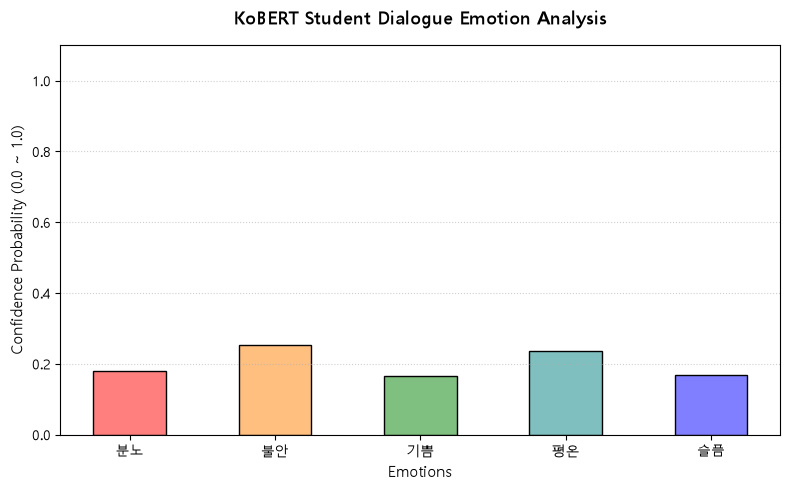

In [4]:
import platform
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rc

# 가속 연산 디바이스(GPU/MPS) 자동 설정
# CUDA(NVIDIA) -> MPS(Mac 인텔/실리콘) -> CPU 순으로 사용 가능한 자원을 체크합니다.
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if torch.backends.mps.is_available() else 
    "cpu"
)
print(f"현재 연산에 사용 중인 디바이스: {device}")

# matplotlib 한글 깨짐 방지 설정 
if platform.system() == 'Darwin':      # macOS 환경
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':   # Windows 환경
    rc('font', family='Malgun Gothic')
    
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지


# 사전 학습된 KoBERT 감정 분류 모델 및 토크나이저 로드
model_name = "rkdaldus/ko-sent5-classification"
tokenizer = AutoTokenizer.from_pretrained("monologg/kobert", trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)

# 분석 대상 입력 텍스트 정의
text_to_analyze = "오늘 동아리 첫 모임에 나갔는데 선배들도 잘 챙겨주고 다들 착해서 너무 신났어!"

# 텍스트 토큰화 및 PyTorch 텐서 변환
encoded_inputs = tokenizer(text_to_analyze, return_tensors="pt", padding=True, truncation=True).to(device)

# 모델 추론을 통한 로짓(Logits) 값 추출
with torch.no_grad():
    model_outputs = model(**encoded_inputs)
    logits = model_outputs.logits

# Softmax 함수를 적용하여 감정별 확률 계산
calculated_probabilities = torch.nn.functional.softmax(logits, dim=-1).squeeze().tolist()

# 감정 레이블 매핑 및 데이터프레임 변환
emotion_labels = ["분노", "불안", "기쁨", "평온", "슬픔"]
emotion_df = pd.DataFrame({
    "Emotion": emotion_labels,
    "Probability": calculated_probabilities
})

print("--- 분석 결과 ---")
print(emotion_df)

# 분석 결과 시각화 (막대그래프)
plt.figure(figsize=(8, 5))
bar_colors = ["#ff7f7f", "#ffbf7f", "#7fbf7f", "#7fbfbf", "#7f7fff"]
plt.bar(emotion_df["Emotion"], emotion_df["Probability"], color=bar_colors, edgecolor="black", width=0.5)

plt.title("KoBERT Student Dialogue Emotion Analysis", fontsize=13, fontweight="bold", pad=15)
plt.xlabel("Emotions", fontsize=11)
plt.ylabel("Confidence Probability (0.0 ~ 1.0)", fontsize=11)
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### 2.3 인코더-디코더 모델 활용: KoBART로 뉴스 요약

In [5]:
from transformers import PreTrainedTokenizerFast, BartForConditionalGeneration

# KoBART 요약 모델 및 전용 토크나이저 로드
kobart_identifier = "gogamza/kobart-summarization"
bart_tokenizer = PreTrainedTokenizerFast.from_pretrained(kobart_identifier)
bart_model = BartForConditionalGeneration.from_pretrained(kobart_identifier).to(device)

# 요약 대상 원문 텍스트 정의
campus_news = (
    "최근 대학가에서는 태풍과 급격한 폭염의 장기화로 인해 대면 야외 수업 및 야외 축제 일정을 전면 수정하고 있습니다. "
    "특히 학생들이 준비했던 야외 엠티와 야외 부스 행사 등이 폭우로 인해 전격 취소되거나 실내 세미나실 행사로 전격 전환되고 있습니다. "
    "대학 연합 축제 준비위원회는 학생 안전 확보를 최우선으로 지정하고"
    "실시간 기상 경보 문자 연동 스크립트를 개발해 비상 체계를 구축했습니다."
)

# 텍스트 인코딩 및 토큰화
input_ids = bart_tokenizer.encode(campus_news, return_tensors="pt", max_length=1024, truncation=True).to(device)

# 요약문 생성 (Beam Search 및 반복 방지 옵션 적용)
summary_tokens = bart_model.generate(
    input_ids,
    max_length=80,
    min_length=15,
    num_beams=4,
    no_repeat_ngram_size=3,
    early_stopping=True
)

# 생성된 토큰 디코딩
summarized_result = bart_tokenizer.decode(summary_tokens, skip_special_tokens=True)
print("--- 요약 결과 ---")
print(f"요약문: {summarized_result}")

Loading weights: 100%|██████████| 260/260 [00:00<00:00, 6591.11it/s]


--- 요약 결과 ---
요약문: ['최근 대학가에서는 태풍과 급격한 폭염의 장기화로 인해 대면 야외 수업 및 야외 축제 일정을 전면 수정하고 학생들이 준비했던 야외 엠티와 야외 부스 행사 등이 폭우로 인해 전격 취소되거나 실내 세미나실 행사로 전격 전환되고 있고, 대학 연합 축제 준비위원회는 학생 안전 확보를 최우선으로 지정하고실시간 기상 경보 문자 연동 스크립트를 개발해 비상 체계를 구축했습니다.']


### 2.4 디코더 모델 활용: Gemma로 대화형 텍스트 생성

In [1]:
from transformers import pipeline
import torch

# Gemma 인스트럭션 모델 식별자 설정
gemma_identifier = "google/gemma-2b-it"

# 텍스트 생성 파이프라인 구축 (bfloat16 연산 및 자원 자동 배치 적용)
gemma_generator = pipeline(
    "text-generation",
    model=gemma_identifier,
    dtype=torch.bfloat16,
    device_map="auto" # accelerate를 통해 OS별 하드웨어(CUDA/MPS) 최적 자동 할당
)

# 대화형 프롬프트 구조 정의
user_dialogue = [
    {"role": "user", "content": "머신러닝과 딥러닝의 핵심 차이점을 비전공자 대학생에게 딱 한 문장으로 비유해서 알려줘."}
]

# 답변 생성
generation_outputs = gemma_generator(user_dialogue, max_new_tokens=150)

# 최종 답변 추출 및 출력
ai_reply = generation_outputs[0]["generated_text"][-1]["content"]
print("--- Gemma 답변 ---")
print(f"Gemma의 답변:\n{ai_reply}")

Loading weights:   0%|          | 0/164 [00:00<?, ?it/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


--- Gemma 답변 ---
Gemma의 답변:
머신러닝은 데이터를 통해 자동적으로 패턴을 찾아 훈련하는 과정이고, 딥러닝은 데이터의 복잡한 패턴을 찾아 훈련하는 과정입니다.
